In [4]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

df = pd.read_csv('../data/subscriptions.csv')

df['plan_encoded'] = df['plan'].map(
    {'starter':0, 'growth':1, 'pro':2, 'enterprise':3}
)
df['churned'] = (df['status'] == 'churned').astype(int)

features = ['tenure_months','mrr','avg_dau','login_days_30',
            'features_used','support_tickets','plan_encoded']

X = df[features].fillna(0)
y = df['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

rf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
print(f"✅ AUC-ROC: {auc:.3f}")

✅ AUC-ROC: 0.642


In [5]:
df['churn_probability'] = rf.predict_proba(X)[:,1]

at_risk = df[
    (df['churn_probability'] > 0.5) & (df['status'] == 'active')
].sort_values('mrr', ascending=False)

print(f"At-risk customers: {len(at_risk)}")
print(f"Revenue at risk: ${at_risk['mrr'].sum():,.0f}/month")

# Save scored data for Streamlit
df.to_csv('../data/subscriptions_scored.csv', index=False)
at_risk.to_csv('../data/at_risk_customers.csv', index=False)

at_risk[['customer_id','plan','mrr','churn_probability']].head(10)

At-risk customers: 0
Revenue at risk: $0/month


,customer_id,plan,mrr,churn_probability


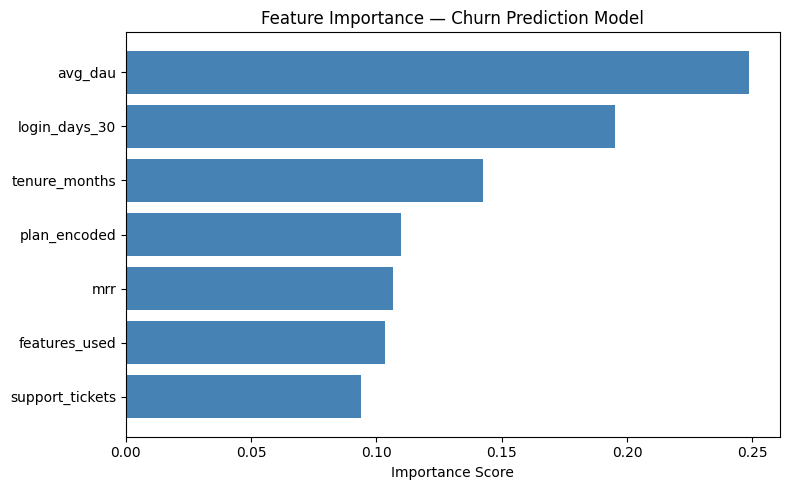

✅ Chart saved


In [6]:
import matplotlib.pyplot as plt
import pandas as pd

importance_df = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
ax.set_title('Feature Importance — Churn Prediction Model')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150)
plt.show()
print("✅ Chart saved")